In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from IQAEBinom_OnlyFinalRound_EndCIReachTol import IQAEBinom_OnlyFinalRound_EndCIReachTol

In [2]:
nShotUnit = 1
epsilon = 0.001
alpha = 0.05

In [3]:
# 次のroundに行く場合はNaNとする
pTrue = 0.49501
thetaTrue = np.arcsin(np.sqrt(pTrue))
nEstim = 10000
minRatio = 2
nGrovers = np.arange(250, 401, 10)
angleFracs = np.linspace(0, 1, num=42)[1:-1] # (2*nGrov + 1) * theta / pi の小数部分の意
resDf = pd.DataFrame(columns=["nGrover","r","AngleFrac","Bias","NumSamp","NumEnd"])

for nGrover in nGrovers:

    r = int((2 * nGrover + 1) * thetaTrue / np.pi)

    for angleFrac in angleFracs:
        print(nGrover, angleFrac, datetime.datetime.now())
        thetaTemp = (r + angleFrac) * np.pi / (2 * nGrover + 1)
        p = np.sin(thetaTemp) ** 2
        errs = []
        for i in range(nEstim):
            result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2, endCriterion="Angle")
            if result is None:
                errs.append(np.nan)
            else:
                pEst = result["Estimate"]
                errs.append(pEst - p)
                # if np.sum(np.logical_not(np.isnan(errThetas))) >= nSamp:
                #     break
        errMean = np.nanmean(errs)
        numSamp = len(errs)
        numEnd = numSamp - np.sum(np.isnan(errs))
        resDf = resDf.append(pd.Series([nGrover,r,angleFrac,errMean,numSamp,numEnd], index=resDf.columns), ignore_index=True)

250 0.024390243902439025 2023-09-12 15:42:24.865217
250 0.04878048780487805 2023-09-12 15:42:26.127222
250 0.07317073170731708 2023-09-12 15:42:27.463531
250 0.0975609756097561 2023-09-12 15:42:28.889714
250 0.12195121951219512 2023-09-12 15:42:30.482786
250 0.14634146341463417 2023-09-12 15:42:32.113579
250 0.17073170731707318 2023-09-12 15:42:34.157933
250 0.1951219512195122 2023-09-12 15:42:36.389635
250 0.21951219512195122 2023-09-12 15:42:39.281204
250 0.24390243902439024 2023-09-12 15:42:42.345041
250 0.2682926829268293 2023-09-12 15:42:45.479340
250 0.29268292682926833 2023-09-12 15:42:48.471186
250 0.3170731707317073 2023-09-12 15:42:51.279040
250 0.34146341463414637 2023-09-12 15:42:53.922527
250 0.36585365853658536 2023-09-12 15:42:56.174257
250 0.3902439024390244 2023-09-12 15:42:58.068999
250 0.41463414634146345 2023-09-12 15:42:59.766494
250 0.43902439024390244 2023-09-12 15:43:01.405992
250 0.4634146341463415 2023-09-12 15:43:02.951379
250 0.4878048780487805 2023-09-12 15

In [4]:
resDf.to_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/Bias_VariousNGrovAngleFrac_p0.49501_nG250-400.csv", index=False)

In [5]:
resDf

,nGrover,r,AngleFrac,Bias,NumSamp,NumEnd
0,250.0,124.0,0.024390,-0.000133,10000.0,10000.0
1,250.0,124.0,0.048780,-0.000221,10000.0,10000.0
2,250.0,124.0,0.073171,-0.000275,10000.0,10000.0
3,250.0,124.0,0.097561,-0.000289,10000.0,10000.0
4,250.0,124.0,0.121951,-0.000307,10000.0,10000.0
...,...,...,...,...,...,...
635,400.0,198.0,0.878049,0.000212,10000.0,10000.0
636,400.0,198.0,0.902439,0.000211,10000.0,10000.0
637,400.0,198.0,0.926829,0.000175,10000.0,10000.0
638,400.0,198.0,0.951220,0.000149,10000.0,10000.0


In [6]:
resDf["Bias"]

0     -0.000133
1     -0.000221
2     -0.000275
3     -0.000289
4     -0.000307
         ...   
635    0.000212
636    0.000211
637    0.000175
638    0.000149
639    0.000083
Name: Bias, Length: 640, dtype: float64

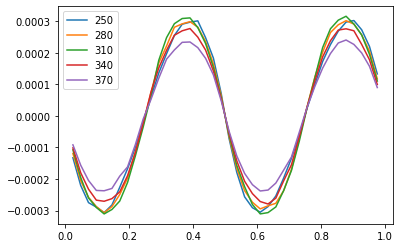

In [7]:
ax = plt.gca()
for nG in [250, 280, 310, 340, 370]:
    resDfPart = resDf[resDf["nGrover"] == nG]
    plt.plot(resDfPart["AngleFrac"], resDfPart["Bias"], label=str(nG))
plt.legend()
plt.show()

In [8]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230911_VariousP_EndCondTheta/results_IQAE_pTrue0.49500999999999995_epsilon0001_alpha005.dat", 'rb') as f:
    results049501 = pickle.load(f)

In [9]:
nGroversExp = np.array([r["nGrover"][-1] for r in results049501])
angleFracExp = np.modf((2 * nGroversExp + 1) * thetaTrue / np.pi)[0]

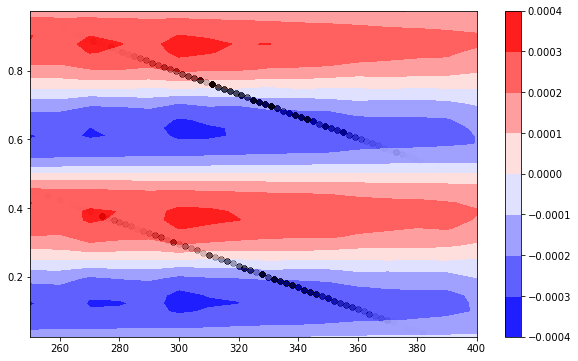

In [23]:
fig, ax1 = plt.subplots(1,figsize=(10,6))

ax1.contourf(nGrovers, angleFracs, np.reshape(np.array(resDf["Bias"]), (len(nGrovers), len(angleFracs))).T, cmap="bwr")    #等高線表示
cntr1 = ax1.contourf(nGrovers, angleFracs, np.reshape(np.array(resDf["Bias"]), (len(nGrovers), len(angleFracs))).T, cmap="bwr")
fig.colorbar(cntr1, ax=ax1)

#ax1 = plt.colorbar(label="contour level")

ax1.scatter(nGroversExp,angleFracExp, c="k", alpha=0.005)

ax1.set_xlim(250,400)

plt.show()

In [26]:
nGrovers = np.arange(150, 241, 10)
angleFracs = np.linspace(0, 1, num=42)[1:-1] # (2*nGrov + 1) * theta / pi の小数部分の意
resDf2 = pd.DataFrame(columns=["nGrover","r","AngleFrac","Bias","NumSamp","NumEnd"])

for nGrover in nGrovers:

    r = int((2 * nGrover + 1) * thetaTrue / np.pi)

    for angleFrac in angleFracs:
        print(nGrover, angleFrac, datetime.datetime.now())
        thetaTemp = (r + angleFrac) * np.pi / (2 * nGrover + 1)
        p = np.sin(thetaTemp) ** 2
        errs = []
        for i in range(nEstim):
            result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2, endCriterion="Angle")
            if result is None:
                errs.append(np.nan)
            else:
                pEst = result["Estimate"]
                errs.append(pEst - p)
                # if np.sum(np.logical_not(np.isnan(errThetas))) >= nSamp:
                #     break
        errMean = np.nanmean(errs)
        numSamp = len(errs)
        numEnd = numSamp - np.sum(np.isnan(errs))
        resDf2 = resDf2.append(pd.Series([nGrover,r,angleFrac,errMean,numSamp,numEnd], index=resDf.columns), ignore_index=True)

150 0.024390243902439025 2023-09-12 17:01:16.070326


<ipython-input-26-844c68cd7479>:23: RuntimeWarning: Mean of empty slice
  errMean = np.nanmean(errs)


150 0.04878048780487805 2023-09-12 17:01:22.165155
150 0.07317073170731708 2023-09-12 17:01:28.614954
150 0.0975609756097561 2023-09-12 17:01:35.769770
150 0.12195121951219512 2023-09-12 17:01:45.089736
150 0.14634146341463417 2023-09-12 17:01:57.217616
150 0.17073170731707318 2023-09-12 17:02:12.095731
150 0.1951219512195122 2023-09-12 17:02:30.455527
150 0.21951219512195122 2023-09-12 17:02:45.144656
150 0.24390243902439024 2023-09-12 17:02:58.160639
150 0.2682926829268293 2023-09-12 17:03:09.224447
150 0.29268292682926833 2023-09-12 17:03:18.318712
150 0.3170731707317073 2023-09-12 17:03:27.767965
150 0.34146341463414637 2023-09-12 17:03:42.385989
150 0.36585365853658536 2023-09-12 17:04:05.445180
150 0.3902439024390244 2023-09-12 17:04:32.007847
150 0.41463414634146345 2023-09-12 17:04:54.444703
150 0.43902439024390244 2023-09-12 17:05:11.465246
150 0.4634146341463415 2023-09-12 17:05:24.531664
150 0.4878048780487805 2023-09-12 17:05:35.304823
150 0.5121951219512195 2023-09-12 17:0

In [28]:
resDf2.to_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/Bias_VariousNGrovAngleFrac_p0.49501_nG150-240.csv", index=False)

In [29]:
resDfComb = pd.read_csv('C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/Bias_VariousNGrovAngleFrac_p0.49501.csv')

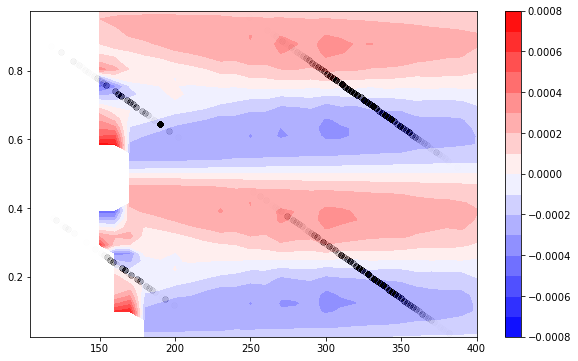

In [32]:
nGrovers = np.arange(150, 401, 10)

fig, ax1 = plt.subplots(1,figsize=(10,6))

levels = np.arange(-0.0008, 0.00081, 0.0001)

ax1.contourf(nGrovers, angleFracs, np.reshape(np.array(resDfComb["Bias"]), (len(nGrovers), len(angleFracs))).T, cmap="bwr", levels=levels)    #等高線表示
cntr1 = ax1.contourf(nGrovers, angleFracs, np.reshape(np.array(resDfComb["Bias"]), (len(nGrovers), len(angleFracs))).T, cmap="bwr", levels=levels)
fig.colorbar(cntr1, ax=ax1)

#ax1 = plt.colorbar(label="contour level")

ax1.scatter(nGroversExp,angleFracExp, c="k", alpha=0.005)

plt.show()

In [34]:
resDfComb[:50]

,nGrover,r,AngleFrac,Bias,NumSamp,NumEnd
0,150.0,74.0,0.024390,NaN,10000.0,0.0
1,150.0,74.0,0.048780,NaN,10000.0,0.0
2,150.0,74.0,0.073171,NaN,10000.0,0.0
3,150.0,74.0,0.097561,NaN,10000.0,0.0
4,150.0,74.0,0.121951,NaN,10000.0,0.0
5,150.0,74.0,0.146341,NaN,10000.0,0.0
6,150.0,74.0,0.170732,NaN,10000.0,0.0
7,150.0,74.0,0.195122,NaN,10000.0,0.0
8,150.0,74.0,0.219512,NaN,10000.0,0.0
9,150.0,74.0,0.243902,NaN,10000.0,0.0
